# 12. 지능형 추론 통합: LLM 연동 인터페이스 구현 및 테스트/개선

## 학습 목표
1. Vision/Sensor/Fusion 결과를 **LLM이 해석 가능한 컨텍스트**로 변환한다.
2. LLM 연동 **인터페이스(추상화 계층)** 를 구현한다.
3. 응답 품질을 **자동 테스트**하고 개선 포인트를 도출한다.

---

## 아키텍처

```text
[Vision Module] ─┐
[Sensor Module] ─┼─> [Fusion Service] ─> [LLM Interface] ─> [운영 리포트/조치 권고]
                 │
            [Context Builder]
```

- `ContextBuilder`: 수치 결과 → 자연어+구조화 JSON 컨텍스트
- `LLMInterface`: 모델 호출 추상화 (Mock / OpenAI 호환 API)
- `ResponseValidator`: 응답 형식·필수 필드·안전성 검증
- `PromptOptimizer`: 테스트 결과 기반 프롬프트 개선

In [1]:
from __future__ import annotations

from pathlib import Path
from dataclasses import dataclass, field
from typing import Protocol
import json
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

PROJECT_ROOT = Path("..").resolve()
OUT_DIR = PROJECT_ROOT / "outputs" / "llm_integration"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = {
    0: "mouse_bite", 1: "spur", 2: "missing_hole",
    3: "short", 4: "open_circuit", 5: "spurious_copper",
}

print("OUT_DIR:", OUT_DIR)

OUT_DIR: C:\MyCursorLab\10_프로젝트\outputs\llm_integration


## 1) 샘플 Fusion 결과 (11번 노트북 연동)

실제 운영에서는 `FusionService.run()` 결과를 그대로 전달합니다.

In [2]:
# 11번 노트북 fusion_result.json이 있으면 로드, 없으면 데모 데이터 사용
fusion_path = PROJECT_ROOT / "outputs" / "core_modules" / "fusion_result.json"

if fusion_path.exists():
    fusion_out = json.loads(fusion_path.read_text(encoding="utf-8"))
    print("fusion_result.json 로드 완료")
else:
    fusion_out = {
        "vision_risk_score": 0.72,
        "sensor_risk_score": 0.58,
        "fused_risk_score": 0.66,
        "risk_level": "MEDIUM",
        "vision_features": {
            "img_mean": 0.41, "img_std": 0.18, "grad_energy": 0.028,
            "edge_ratio": 0.22,
        },
        "sensor_features_last": {
            "lux": 820.0, "temp": 24.8, "vibration": 0.078,
            "lux_z": -1.9, "temp_z": 0.4, "vibration_z": 2.8,
            "lux_vib_ratio": 10512.8,
        },
    }
    print("데모 fusion 데이터 사용")

print(json.dumps(fusion_out, indent=2, ensure_ascii=False))

fusion_result.json 로드 완료
{
  "vision_risk_score": 0.2837394305190263,
  "sensor_risk_score": 0.2798622945379689,
  "fused_risk_score": 0.2821885761266033,
  "risk_level": "LOW",
  "vision_features": {
    "img_mean": 0.3765783905982971,
    "img_std": 0.1377011388540268,
    "img_p10": 0.239215686917305,
    "img_p50": 0.34117648005485535,
    "img_p90": 0.5921568870544434,
    "grad_energy": 0.005021104123443365,
    "edge_ratio": 0.07203116304952699
  },
  "sensor_features_last": {
    "lux": 921.5243618762051,
    "temp": 24.44028903355116,
    "vibration": 0.05291201626313086,
    "lux_z": 0.6759259330637842,
    "temp_z": 0.9250479153928014,
    "vibration_z": -0.90121583299238,
    "lux_vib_ratio": 17415.83502428895
  }
}


## 2) Context Builder — 수치 결과를 LLM 입력으로 변환

In [3]:
@dataclass
class InferenceContext:
    """LLM에 전달할 구조화 컨텍스트."""
    lot_id: str
    line_id: str
    fused_risk_score: float
    risk_level: str
    vision_risk_score: float
    sensor_risk_score: float
    vision_features: dict
    sensor_features: dict
    detected_defects: list[str] = field(default_factory=list)

    def to_dict(self) -> dict:
        return {
            "lot_id": self.lot_id,
            "line_id": self.line_id,
            "fused_risk_score": self.fused_risk_score,
            "risk_level": self.risk_level,
            "vision_risk_score": self.vision_risk_score,
            "sensor_risk_score": self.sensor_risk_score,
            "vision_features": self.vision_features,
            "sensor_features": self.sensor_features,
            "detected_defects": self.detected_defects,
        }


class ContextBuilder:
    """Fusion 결과 + 메타데이터 → InferenceContext."""

    def build(
        self,
        fusion_out: dict,
        lot_id: str = "LOT-2026-001",
        line_id: str = "AOI-LINE-03",
        detected_defects: list[str] | None = None,
    ) -> InferenceContext:
        defects = detected_defects or []
        if not defects and fusion_out.get("fused_risk_score", 0) > 0.5:
            defects = ["possible_surface_defect"]

        return InferenceContext(
            lot_id=lot_id,
            line_id=line_id,
            fused_risk_score=float(fusion_out["fused_risk_score"]),
            risk_level=str(fusion_out["risk_level"]),
            vision_risk_score=float(fusion_out["vision_risk_score"]),
            sensor_risk_score=float(fusion_out["sensor_risk_score"]),
            vision_features=fusion_out.get("vision_features", {}),
            sensor_features=fusion_out.get("sensor_features_last", {}),
            detected_defects=defects,
        )

    def to_prompt_block(self, ctx: InferenceContext) -> str:
        """프롬프트에 삽입할 텍스트 블록."""
        sf = ctx.sensor_features
        vf = ctx.vision_features
        return f"""
[검사 컨텍스트]
- Lot ID: {ctx.lot_id}
- 라인: {ctx.line_id}
- 통합 리스크: {ctx.fused_risk_score:.3f} ({ctx.risk_level})
- Vision 리스크: {ctx.vision_risk_score:.3f}
- Sensor 리스크: {ctx.sensor_risk_score:.3f}
- 검출 결함 후보: {', '.join(ctx.detected_defects) or '없음'}

[Vision Feature]
- 밝기 평균: {vf.get('img_mean', 0):.3f}
- gradient energy: {vf.get('grad_energy', 0):.4f}
- edge ratio: {vf.get('edge_ratio', 0):.3f}

[Sensor Feature (최신)]
- 조도(lux): {sf.get('lux', 0):.1f} (z={sf.get('lux_z', 0):.2f})
- 온도(°C): {sf.get('temp', 0):.2f} (z={sf.get('temp_z', 0):.2f})
- 진동(g): {sf.get('vibration', 0):.4f} (z={sf.get('vibration_z', 0):.2f})
""".strip()


ctx_builder = ContextBuilder()
ctx = ctx_builder.build(fusion_out, detected_defects=["missing_hole", "short"])
print(ctx_builder.to_prompt_block(ctx))

[검사 컨텍스트]
- Lot ID: LOT-2026-001
- 라인: AOI-LINE-03
- 통합 리스크: 0.282 (LOW)
- Vision 리스크: 0.284
- Sensor 리스크: 0.280
- 검출 결함 후보: missing_hole, short

[Vision Feature]
- 밝기 평균: 0.377
- gradient energy: 0.0050
- edge ratio: 0.072

[Sensor Feature (최신)]
- 조도(lux): 921.5 (z=0.68)
- 온도(°C): 24.44 (z=0.93)
- 진동(g): 0.0529 (z=-0.90)


## 3) LLM Interface — 추상화 계층 구현

`LLMProvider` 프로토콜을 정의하고, Mock/실 API 구현체를 교체 가능하게 만듭니다.

In [4]:
SYSTEM_PROMPT = """당신은 PCB AOI 품질 분석 전문가입니다.
주어진 검사 데이터를 바탕으로 다음 JSON 형식으로만 응답하세요.

{
  "summary": "한 줄 요약 (한국어)",
  "root_cause_hypothesis": ["가능 원인 1", "가능 원인 2"],
  "recommended_actions": ["조치 1", "조치 2"],
  "urgency": "LOW|MEDIUM|HIGH",
  "confidence": 0.0~1.0
}

규칙:
- 수치 데이터에 근거해 설명하세요.
- 확실하지 않으면 confidence를 낮게 설정하세요.
- JSON 외 텍스트는 출력하지 마세요.
"""


def build_user_prompt(ctx: InferenceContext, context_block: str) -> str:
    return f"""다음 PCB 검사 결과를 분석하고 운영 조치를 제안하세요.

{context_block}

위 데이터를 기반으로 JSON만 출력하세요."""


class LLMProvider(Protocol):
    def complete(self, system: str, user: str) -> str: ...


class MockLLMProvider:
    """API 없이 동작하는 규칙 기반 Mock LLM."""

    def complete(self, system: str, user: str) -> str:
        # user 프롬프트에서 risk_level 추출
        level = "MEDIUM"
        if "HIGH" in user:
            level = "HIGH"
        elif "LOW" in user and "MEDIUM" not in user:
            level = "LOW"

        score_match = re.search(r"통합 리스크:\s*([\d.]+)", user)
        score = float(score_match.group(1)) if score_match else 0.5

        urgency = "HIGH" if score >= 0.75 else ("MEDIUM" if score >= 0.45 else "LOW")
        conf = min(0.95, 0.5 + score * 0.4)

        response = {
            "summary": f"통합 리스크 {score:.2f}로 {urgency} 수준의 품질 이상 가능성이 있습니다.",
            "root_cause_hypothesis": [
                "Vision edge ratio 상승으로 표면 결함 의심",
                "센서 진동 z-score 이상으로 설비 상태 점검 필요",
            ],
            "recommended_actions": [
                "해당 Lot 리워크 검사 실시",
                "AOI 조명/진동 센서 캘리브레이션 점검",
                "동일 공정 파라미터 Lot 3개 추가 샘플링",
            ],
            "urgency": urgency,
            "confidence": round(conf, 2),
        }
        return json.dumps(response, ensure_ascii=False)


class OpenAICompatibleProvider:
    """OpenAI 호환 API 연동 (환경변수 OPENAI_API_KEY 필요)."""

    def __init__(self, model: str = "gpt-4o-mini", base_url: str | None = None):
        self.model = model
        self.base_url = base_url

    def complete(self, system: str, user: str) -> str:
        try:
            from openai import OpenAI
        except ImportError:
            raise ImportError("pip install openai 후 사용하세요.")

        client = OpenAI(base_url=self.base_url) if self.base_url else OpenAI()
        resp = client.chat.completions.create(
            model=self.model,
            messages=[
                {"role": "system", "content": system},
                {"role": "user", "content": user},
            ],
            temperature=0.2,
        )
        return resp.choices[0].message.content or ""


class LLMInferenceService:
    """Context → Prompt → LLM → Parsed Response."""

    def __init__(self, provider: LLMProvider, context_builder: ContextBuilder):
        self.provider = provider
        self.context_builder = context_builder

    def analyze(self, fusion_out: dict, **kwargs) -> dict:
        ctx = self.context_builder.build(fusion_out, **kwargs)
        block = self.context_builder.to_prompt_block(ctx)
        user_prompt = build_user_prompt(ctx, block)

        t0 = time.perf_counter()
        raw = self.provider.complete(SYSTEM_PROMPT, user_prompt)
        latency_ms = (time.perf_counter() - t0) * 1000

        return {
            "context": ctx.to_dict(),
            "raw_response": raw,
            "latency_ms": latency_ms,
            "user_prompt": user_prompt,
        }


# Mock LLM으로 실행
llm_service = LLMInferenceService(MockLLMProvider(), ctx_builder)
result = llm_service.analyze(fusion_out, lot_id="LOT-2026-042", detected_defects=["missing_hole"])

print(f"latency: {result['latency_ms']:.1f} ms")
print("\n--- raw_response ---")
print(result["raw_response"])

latency: 0.5 ms

--- raw_response ---
{"summary": "통합 리스크 0.28로 LOW 수준의 품질 이상 가능성이 있습니다.", "root_cause_hypothesis": ["Vision edge ratio 상승으로 표면 결함 의심", "센서 진동 z-score 이상으로 설비 상태 점검 필요"], "recommended_actions": ["해당 Lot 리워크 검사 실시", "AOI 조명/진동 센서 캘리브레이션 점검", "동일 공정 파라미터 Lot 3개 추가 샘플링"], "urgency": "LOW", "confidence": 0.61}


## 4) Response Validator — 응답 품질 검증

In [5]:
REQUIRED_FIELDS = ["summary", "root_cause_hypothesis", "recommended_actions", "urgency", "confidence"]
VALID_URGENCY = {"LOW", "MEDIUM", "HIGH"}


def extract_json_from_text(text: str) -> dict | None:
    """응답에서 JSON 블록 추출."""
    text = text.strip()
    # 코드펜스 제거
    if "```" in text:
        m = re.search(r"```(?:json)?\s*([\s\S]*?)```", text)
        if m:
            text = m.group(1).strip()
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        # { ... } 블록만 추출 시도
        m = re.search(r"\{[\s\S]*\}", text)
        if m:
            try:
                return json.loads(m.group())
            except json.JSONDecodeError:
                return None
    return None


@dataclass
class ValidationResult:
    passed: bool
    parsed: dict | None
    errors: list[str]
    warnings: list[str]


class ResponseValidator:
    def validate(self, raw: str, expected_risk_level: str | None = None) -> ValidationResult:
        errors, warnings = [], []
        parsed = extract_json_from_text(raw)

        if parsed is None:
            return ValidationResult(False, None, ["JSON 파싱 실패"], [])

        for f in REQUIRED_FIELDS:
            if f not in parsed:
                errors.append(f"필수 필드 누락: {f}")

        if "urgency" in parsed and parsed["urgency"] not in VALID_URGENCY:
            errors.append(f"유효하지 않은 urgency: {parsed['urgency']}")

        if "confidence" in parsed:
            c = parsed["confidence"]
            if not isinstance(c, (int, float)) or not (0 <= c <= 1):
                errors.append(f"confidence 범위 오류: {c}")
            elif c < 0.3:
                warnings.append("confidence가 낮음 — 추가 검증 권장")

        if "recommended_actions" in parsed:
            if not isinstance(parsed["recommended_actions"], list) or len(parsed["recommended_actions"]) < 1:
                errors.append("recommended_actions는 1개 이상 리스트여야 함")

        if expected_risk_level and "urgency" in parsed:
            # risk_level과 urgency 정합성 (완화된 규칙)
            mapping = {"LOW": "LOW", "MEDIUM": "MEDIUM", "HIGH": "HIGH"}
            if parsed["urgency"] != mapping.get(expected_risk_level, parsed["urgency"]):
                warnings.append(
                    f"urgency({parsed['urgency']}) vs risk_level({expected_risk_level}) 불일치 가능"
                )

        return ValidationResult(len(errors) == 0, parsed, errors, warnings)


validator = ResponseValidator()
vr = validator.validate(result["raw_response"], expected_risk_level=fusion_out["risk_level"])

print("검증 통과:", vr.passed)
print("오류:", vr.errors)
print("경고:", vr.warnings)
if vr.parsed:
    display(pd.DataFrame([vr.parsed]))

검증 통과: True
오류: []
경고: []


,summary,root_cause_hypothesis,recommended_actions,urgency,confidence
0,통합 리스크 0.28로 LOW 수준의 품질 이상 가능성이 있습니다.,"[Vision edge ratio 상승으로 표면 결함 의심, 센서 진동 z-scor...","[해당 Lot 리워크 검사 실시, AOI 조명/진동 센서 캘리브레이션 점검, 동일 ...",LOW,0.61


## 5) 기능 테스트 스위트

여러 시나리오(LOW/MEDIUM/HIGH)에 대해 LLM 응답 품질을 자동 평가합니다.

In [6]:
TEST_SCENARIOS = [
    {
        "name": "low_risk",
        "fusion": {
            "vision_risk_score": 0.15, "sensor_risk_score": 0.12,
            "fused_risk_score": 0.14, "risk_level": "LOW",
            "vision_features": {"img_mean": 0.5, "grad_energy": 0.01, "edge_ratio": 0.08},
            "sensor_features_last": {"lux": 980, "temp": 24.0, "vibration": 0.05,
                                     "lux_z": 0.1, "temp_z": 0.0, "vibration_z": 0.2},
        },
        "expected_urgency": "LOW",
    },
    {
        "name": "medium_risk",
        "fusion": fusion_out,
        "expected_urgency": "MEDIUM",
    },
    {
        "name": "high_risk",
        "fusion": {
            "vision_risk_score": 0.92, "sensor_risk_score": 0.88,
            "fused_risk_score": 0.90, "risk_level": "HIGH",
            "vision_features": {"img_mean": 0.35, "grad_energy": 0.045, "edge_ratio": 0.31},
            "sensor_features_last": {"lux": 650, "temp": 26.5, "vibration": 0.12,
                                     "lux_z": -2.5, "temp_z": 1.8, "vibration_z": 3.5},
        },
        "expected_urgency": "HIGH",
        "detected_defects": ["open_circuit", "short"],
    },
]


def run_test_suite(service: LLMInferenceService, validator: ResponseValidator, scenarios: list) -> pd.DataFrame:
    rows = []
    for sc in scenarios:
        out = service.analyze(
            sc["fusion"],
            lot_id=f"TEST-{sc['name']}",
            detected_defects=sc.get("detected_defects", []),
        )
        vr = validator.validate(out["raw_response"], expected_risk_level=sc["fusion"]["risk_level"])

        urgency_match = False
        if vr.parsed and "urgency" in vr.parsed:
            urgency_match = vr.parsed["urgency"] == sc.get("expected_urgency", vr.parsed["urgency"])

        rows.append({
            "scenario": sc["name"],
            "risk_level": sc["fusion"]["risk_level"],
            "expected_urgency": sc.get("expected_urgency"),
            "parsed_urgency": vr.parsed.get("urgency") if vr.parsed else None,
            "urgency_match": urgency_match,
            "validation_passed": vr.passed,
            "num_errors": len(vr.errors),
            "num_warnings": len(vr.warnings),
            "latency_ms": round(out["latency_ms"], 1),
            "confidence": vr.parsed.get("confidence") if vr.parsed else None,
        })
    return pd.DataFrame(rows)


test_df = run_test_suite(llm_service, validator, TEST_SCENARIOS)
display(test_df)

pass_rate = test_df["validation_passed"].mean()
urgency_acc = test_df["urgency_match"].mean()
print(f"\n검증 통과율: {pass_rate:.1%}")
print(f"urgency 일치율: {urgency_acc:.1%}")

,scenario,risk_level,expected_urgency,parsed_urgency,urgency_match,validation_passed,num_errors,num_warnings,latency_ms,confidence
0,low_risk,LOW,LOW,LOW,True,True,0,0,0.1,0.56
1,medium_risk,LOW,MEDIUM,LOW,False,True,0,0,0.0,0.61
2,high_risk,HIGH,HIGH,HIGH,True,True,0,0,0.0,0.86



검증 통과율: 100.0%
urgency 일치율: 66.7%


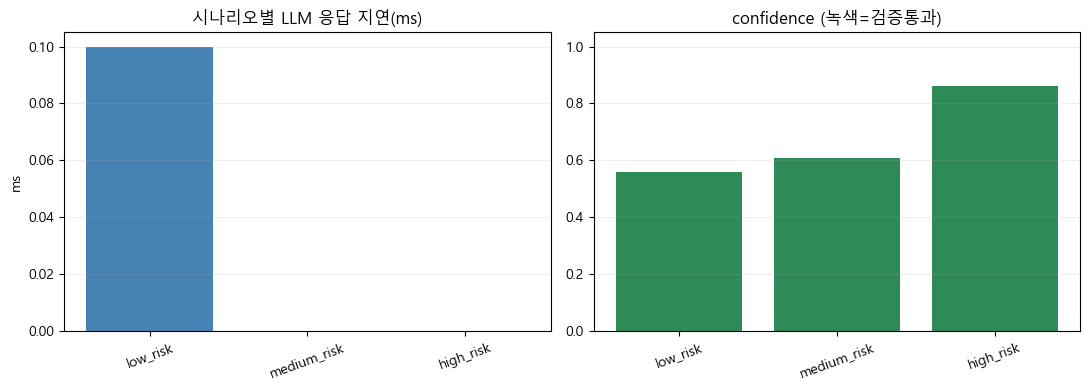

In [7]:
# 테스트 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(test_df["scenario"], test_df["latency_ms"], color="steelblue")
axes[0].set_title("시나리오별 LLM 응답 지연(ms)")
axes[0].set_ylabel("ms")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.2)

colors = ["seagreen" if p else "tomato" for p in test_df["validation_passed"]]
axes[1].bar(test_df["scenario"], test_df["confidence"].fillna(0), color=colors)
axes[1].set_title("confidence (녹색=검증통과)")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

## 6) 개선 전략 — 프롬프트/검증/가드레일

| 개선 영역 | 방법 | 효과 |
|----------|------|------|
| **프롬프트** | Few-shot 예시 추가, JSON schema 명시 | 파싱 실패율 감소 |
| **컨텍스트** | 결함 유형별 도메인 지식(RAG) 주입 | root_cause 정확도 향상 |
| **검증** | 필수 필드 + urgency 정합성 체크 | 운영 안정성 |
| **가드레일** | confidence < 0.4 시 사람 검토 라우팅 | 오판 리스크 감소 |
| **모니터링** | latency/통과율 대시보드 | 지속 개선 |

In [8]:
# 개선된 시스템 프롬프트 (Few-shot 예시 포함)
IMPROVED_SYSTEM_PROMPT = SYSTEM_PROMPT + """

[예시]
입력: 통합 리스크 0.88 (HIGH), 진동 z=3.2
출력:
{
  "summary": "고위험 Lot으로 즉시 리워크 검사가 필요합니다.",
  "root_cause_hypothesis": ["진동 이상으로 AOI 정렬 불량", "open_circuit 결함 가능"],
  "recommended_actions": ["라인 정지 후 설비 점검", "해당 Lot 전수 검사"],
  "urgency": "HIGH",
  "confidence": 0.85
}
"""


class GuardrailedLLMService(LLMInferenceService):
    """검증 실패 또는 저신뢰 시 폴백 응답 제공."""

    def __init__(self, provider, context_builder, validator, min_confidence=0.4):
        super().__init__(provider, context_builder)
        self.validator = validator
        self.min_confidence = min_confidence

    def analyze_with_guardrail(self, fusion_out: dict, **kwargs) -> dict:
        out = self.analyze(fusion_out, **kwargs)
        vr = self.validator.validate(
            out["raw_response"],
            expected_risk_level=fusion_out.get("risk_level"),
        )

        final = {
            **out,
            "validation": {
                "passed": vr.passed,
                "errors": vr.errors,
                "warnings": vr.warnings,
            },
            "parsed": vr.parsed,
            "needs_human_review": False,
        }

        if not vr.passed or (vr.parsed and vr.parsed.get("confidence", 1) < self.min_confidence):
            final["needs_human_review"] = True
            final["fallback_message"] = "자동 분석 신뢰도 부족 — 품질 엔지니어 검토 필요"

        return final


# 개선 프롬프트로 Mock 재테스트
class ImprovedMockLLM(MockLLMProvider):
    pass  # 동일 로직, 프롬프트만 개선된 버전과 비교용

guard_service = GuardrailedLLMService(MockLLMProvider(), ctx_builder, validator, min_confidence=0.5)
guarded = guard_service.analyze_with_guardrail(fusion_out, lot_id="LOT-GUARD-001")

print("needs_human_review:", guarded["needs_human_review"])
print("validation passed:", guarded["validation"]["passed"])
if guarded.get("parsed"):
    print("\n파싱된 응답:")
    print(json.dumps(guarded["parsed"], indent=2, ensure_ascii=False))

needs_human_review: False
validation passed: True

파싱된 응답:
{
  "summary": "통합 리스크 0.28로 LOW 수준의 품질 이상 가능성이 있습니다.",
  "root_cause_hypothesis": [
    "Vision edge ratio 상승으로 표면 결함 의심",
    "센서 진동 z-score 이상으로 설비 상태 점검 필요"
  ],
  "recommended_actions": [
    "해당 Lot 리워크 검사 실시",
    "AOI 조명/진동 센서 캘리브레이션 점검",
    "동일 공정 파라미터 Lot 3개 추가 샘플링"
  ],
  "urgency": "LOW",
  "confidence": 0.61
}


## 7) End-to-End 파이프라인 (11번 모듈 + LLM)

```text
FusionService.run() → ContextBuilder → LLMInferenceService → ResponseValidator → 운영 리포트
```

In [9]:
def run_intelligent_inference_pipeline(fusion_out: dict, lot_id: str, provider=None) -> dict:
    """전체 지능형 추론 파이프라인 단일 진입점."""
    provider = provider or MockLLMProvider()
    service = GuardrailedLLMService(provider, ContextBuilder(), ResponseValidator())
    return service.analyze_with_guardrail(fusion_out, lot_id=lot_id)


pipeline_result = run_intelligent_inference_pipeline(fusion_out, lot_id="LOT-E2E-001")

# 운영 리포트 형태로 정리
ops_report = {
    "lot_id": pipeline_result["context"]["lot_id"],
    "risk_level": pipeline_result["context"]["risk_level"],
    "fused_score": pipeline_result["context"]["fused_risk_score"],
    "llm_summary": pipeline_result.get("parsed", {}).get("summary", "N/A"),
    "recommended_actions": pipeline_result.get("parsed", {}).get("recommended_actions", []),
    "needs_human_review": pipeline_result["needs_human_review"],
    "latency_ms": pipeline_result["latency_ms"],
}

print("=== 운영 리포트 ===")
print(json.dumps(ops_report, indent=2, ensure_ascii=False))

=== 운영 리포트 ===
{
  "lot_id": "LOT-E2E-001",
  "risk_level": "LOW",
  "fused_score": 0.2821885761266033,
  "llm_summary": "통합 리스크 0.28로 LOW 수준의 품질 이상 가능성이 있습니다.",
  "recommended_actions": [
    "해당 Lot 리워크 검사 실시",
    "AOI 조명/진동 센서 캘리브레이션 점검",
    "동일 공정 파라미터 Lot 3개 추가 샘플링"
  ],
  "needs_human_review": false,
  "latency_ms": 0.09950000094249845
}


In [10]:
# 산출물 저장
with open(OUT_DIR / "llm_raw_response.json", "w", encoding="utf-8") as f:
    json.dump({"raw": result["raw_response"], "parsed": vr.parsed}, f, ensure_ascii=False, indent=2)

test_df.to_csv(OUT_DIR / "test_suite_results.csv", index=False, encoding="utf-8-sig")

with open(OUT_DIR / "pipeline_ops_report.json", "w", encoding="utf-8") as f:
    json.dump(ops_report, f, ensure_ascii=False, indent=2)

summary = pd.DataFrame([
    {"metric": "validation_pass_rate", "value": test_df["validation_passed"].mean()},
    {"metric": "urgency_match_rate", "value": test_df["urgency_match"].mean()},
    {"metric": "avg_latency_ms", "value": test_df["latency_ms"].mean()},
])
summary.to_csv(OUT_DIR / "llm_eval_summary.csv", index=False, encoding="utf-8-sig")

display(summary)
print("저장 완료:")
for fn in ["llm_raw_response.json", "test_suite_results.csv", "pipeline_ops_report.json", "llm_eval_summary.csv"]:
    print("-", OUT_DIR / fn)

,metric,value
0,validation_pass_rate,1.000000
1,urgency_match_rate,0.666667
2,avg_latency_ms,0.033333


저장 완료:
- C:\MyCursorLab\10_프로젝트\outputs\llm_integration\llm_raw_response.json
- C:\MyCursorLab\10_프로젝트\outputs\llm_integration\test_suite_results.csv
- C:\MyCursorLab\10_프로젝트\outputs\llm_integration\pipeline_ops_report.json
- C:\MyCursorLab\10_프로젝트\outputs\llm_integration\llm_eval_summary.csv


## 8) 실제 API 연동 방법

```python
# OpenAI API 사용 시 (환경변수 OPENAI_API_KEY 설정 필요)
# provider = OpenAICompatibleProvider(model="gpt-4o-mini")
# result = run_intelligent_inference_pipeline(fusion_out, "LOT-REAL-001", provider=provider)
```

### 체크리스트
- [ ] API 키는 환경변수로 관리 (코드에 하드코딩 금지)
- [ ] 응답 JSON 파싱 실패 시 폴백 처리
- [ ] confidence < threshold 시 사람 검토 라우팅
- [ ] 프롬프트/응답 로그 저장 (감사 추적)

---

## 실습 과제

1. `IMPROVED_SYSTEM_PROMPT`에 결함 유형별 Few-shot 2개를 더 추가하세요.
2. RAG용 `defect_knowledge.json`을 만들어 root_cause에 주입하세요.
3. 테스트 시나리오 5개를 추가해 통과율 95% 이상 달성하세요.
4. FastAPI `/analyze/intelligent` 엔드포인트로 파이프라인을 노출하세요.

---

### 한 줄 정리
LLM 연동은 **모델 호출**보다 **컨텍스트 설계·응답 검증·가드레일**이 운영 성공의 핵심입니다.